# Setup

In [8]:
%load_ext autoreload
%autoreload 2

# %matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tpvalidator.workspace as workspace
import tpvalidator.analysis.snn as snn

from rich import print


# Code

In [10]:
from typing import Tuple, Optional, Union, Sequence, Dict, List
from rich.table import Table
from tpvalidator.detector_geometry import FDVDGeometry_1x8x14


def make_rates_table_from_workspaces( 
        datasets : Dict[str,workspace.TriggerPrimitivesWorkspace], 
        preselection: str = '', 
        per:str='chan', 
        ro_win_len: int=None) -> pd.DataFrame:
    """
    Calculates the TP rates of each workspace in the dataset list.
    The rate is calculated over the chosen unit specified by the `per` argument: channel, crp, tpc or detector.
    The rates are displayed per unit and per view.

    If a preselection is specified, this is applied to all datasets before the rate calculation.
    The readout window lenght, needed for the rate estimate, is passed as argument.
    """
    
    # Constants : move them somewhere else
    sampling_period = 0.5e-6

    num_el_map = {
        'chan' : lambda v: FDVDGeometry_1x8x14.crp_num_chans_by_view_sim(v)*FDVDGeometry_1x8x14.num_crps,
        'crp' : lambda _: FDVDGeometry_1x8x14.num_crps,
        'tpc' : lambda _: FDVDGeometry_1x8x14.num_tpcs,
        'det' : lambda _: 1,
    }
    
    num_el = num_el_map[per]

    rows=[]
    for s, ws in datasets.items():
        num_ev = ws.num_entries
        # Throw if not available
        ro_win_len = ws._extra_info['readout_window'] if ro_win_len is None else ro_win_len

        total_time = num_ev*ro_win_len*sampling_period 
        tps_sel = ws.tps.query(preselection) if preselection else ws.tps
        tp_rates = []
        for v in range(3):
            num_els = num_el(v)
            tp_rate = len(tps_sel.query(f'readout_view == {v}'))/total_time/num_els
            tp_rates += [tp_rate]
        rows += [(s, total_time, *tp_rates)]

    df = pd.DataFrame(
        np.array(rows, dtype=[("dataset",object), ("time",float), ("U",float), ("V",float), ("X",float)]),
        columns=['dataset','time', 'U', 'V', 'X']
    )

    return df

In [11]:
def make_vd_rates_table_2(datasets : Dict[str,pd.DataFrame], num_events, preselection: str = '', per:str='chan', title: str='', ro_win_len: int=None, sampling_period=5e-6) -> Table:

    num_el_map = {
        'chan' : lambda v: FDVDGeometry_1x8x14.crp_num_chans_by_view_sim(v)*FDVDGeometry_1x8x14.num_crps,
        'crp' : lambda _: FDVDGeometry_1x8x14.num_crps,
        'tpc' : lambda _: FDVDGeometry_1x8x14.num_tpcs,
        'det' : lambda _: 1,
    }

    num_el = num_el_map[per]

    t = Table('sample', 'time', 'U', 'V', 'X', title=title)
    for s, df in datasets.items():
        num_ev = num_events
        
        # Throw if not available
        ro_win_len = df.extra_info['readout_window'] if ro_win_len is None else ro_win_len

        total_time = num_ev*ro_win_len*sampling_period
        row = [s, f'{total_time:.3f} s']
        tps_sel = df.query(preselection) if preselection else df
        for v in range(3):
            num_els = num_el(v)
            noise_rate = len(tps_sel.query(f'readout_view == {v}'))/total_time/num_els
            row += [f'{noise_rate:.2f} Hz']
        t.add_row(*row)
    return t

# Data

In [ ]:
import tpvalidator.datacatalogue as dsl

dataset_name = 'radbkg'
datasets = dsl.load('data/vd/1x8x14/old_detsim', dataset_name)
rad_ws=datasets[dataset_name]


Dataset 'radbkg': 100 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [
        [28, 'Rn222ChainFromPo218GenInUpperMesh1x8x14'],
        [27, 'Rn220ChainFromPb212GenInUpperMesh1x8x14'],
        [26, 'Kr85GenInLAr'],
        [25, 'Rn222ChainFromBi210GenInUpperMesh1x8x14'],
        [24, 'U238ChainGenInAnode'],
        [23, 'K40GenInCathode'],
        [22, 'K42From42ArGenInUpperMesh1x8x14'],
        [21, 'Th232ChainGenInCathode'],
        [20, 'CavernNGammasAtLAr1x8x14'],
        [19, 'Rn222ChainRn222GenInLAr'],
        [18, 'U238ChainGenInCathode'],
        [17, 'K40GenInAnode'],
        [16, 'Rn220ChainPb212GenInLAr'],
        [15, 'foamGammasAtLAr1x8x14'],
        [14, 'Rn222ChainFromPb214GenInUpperMesh1x8x14'],
        [13, 'K42From42ArGenInLAr'],
        [12, 'Rn222ChainGenInPDS'],
        [11, 'Ar42GenInLAr'],
        [10, 'CavernwallGammasAtLAr1x8x14'],
        [9, 'Rn222ChainPb210GenInLAr'],
        [8, 'Ar39GenInLAr'],
        [7, 'Rn222ChainPb214GenInLAr'],
        [6, 'Rn222ChainFromPb210GenInUpperMesh1x8x14'],
        [5, 'Rn222ChainPo218GenInLAr'],
        [4, 'CavernwallNeutronsAtLAr1x8x14'],
        [3, 'Rn222ChainFromBi214GenInUpperMesh1x8x14'],
        [2, 'CryostatNGammasAtLAr1x8x14'],
        [1, 'Th232ChainGenInAnode'],
        [0, 'Rn222ChainBi214GenInLAr']
    ],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 45,
            'threshold_tpg_plane1': 45,
            'threshold_tpg_plane2': 45,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

In [13]:
from tpvalidator.viz.mc import MCPlotter

mcp = MCPlotter(datasets['radbkg'])

In [14]:
mcp.make_generators_table()

             Background generators              
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━┓
┃ generator name                          ┃ id ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━┩
│ Rn222ChainFromPo218GenInUpperMesh1x8x14 │ 28 │
│ Rn220ChainFromPb212GenInUpperMesh1x8x14 │ 27 │
│ Kr85GenInLAr                            │ 26 │
│ Rn222ChainFromBi210GenInUpperMesh1x8x14 │ 25 │
│ U238ChainGenInAnode                     │ 24 │
│ K40GenInCathode                         │ 23 │
│ K42From42ArGenInUpperMesh1x8x14         │ 22 │
│ Th232ChainGenInCathode                  │ 21 │
│ CavernNGammasAtLAr1x8x14                │ 20 │
│ Rn222ChainRn222GenInLAr                 │ 19 │
│ U238ChainGenInCathode                   │ 18 │
│ K40GenInAnode                           │ 17 │
│ Rn220ChainPb212GenInLAr                 │ 16 │
│ foamGammasAtLAr1x8x14                   │ 15 │
│ Rn222ChainFromPb214GenInUpperMesh1x8x14 │ 14 │
│ K42From42ArGenInLAr                     │ 13 │
│ Rn222ChainGenInPDS                      │ 12 │
│ Ar42GenInLAr                            │ 11 │
│ CavernwallGammasAtLAr1x8x14             │ 10 │
│ Rn222ChainPb210GenInLAr                 │ 9  │
│ Ar39GenInLAr                            │ 8  │
│ Rn222ChainPb214GenInLAr                 │ 7  │
│ Rn222ChainFromPb210GenInUpperMesh1x8x14 │ 6  │
│ Rn222ChainPo218GenInLAr                 │ 5  │
│ CavernwallNeutronsAtLAr1x8x14           │ 4  │
│ Rn222ChainFromBi214GenInUpperMesh1x8x14 │ 3  │
│ CryostatNGammasAtLAr1x8x14              │ 2  │
│ Th232ChainGenInAnode                    │ 1  │
│ Rn222ChainBi214GenInLAr                 │ 0  │
└─────────────────────────────────────────┴────┘

In [15]:
mcp.make_generator_rates_table()

               Backgrounds generators by activity                
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━┓
┃ generator name                          ┃ entries ┃ rate [Hz] ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━┩
│ CavernwallGammasAtLAr1x8x14             │ 8374045 │ 9.85e+06  │
│ Ar39GenInLAr                            │ 3110787 │ 3.66e+06  │
│ Th232ChainGenInCathode                  │ 360246  │ 4.24e+05  │
│ Kr85GenInLAr                            │ 355683  │ 4.18e+05  │
│ foamGammasAtLAr1x8x14                   │ 350792  │ 4.13e+05  │
│ U238ChainGenInCathode                   │ 301561  │ 3.55e+05  │
│ Th232ChainGenInAnode                    │ 163408  │ 1.92e+05  │
│ U238ChainGenInAnode                     │ 136246  │ 1.60e+05  │
│ K40GenInCathode                         │ 23110   │ 2.72e+04  │
│ K40GenInAnode                           │ 10683   │ 1.26e+04  │
│ Rn222ChainPb214GenInLAr                 │ 5303    │ 6.24e+03  │
│ Rn222ChainFromBi214GenInUpperMesh1x8x14 │ 5169    │ 6.08e+03  │
│ Rn220ChainFromPb212GenInUpperMesh1x8x14 │ 4929    │ 5.80e+03  │
│ Rn222ChainFromPb210GenInUpperMesh1x8x14 │ 4881    │ 5.74e+03  │
│ Rn222ChainBi214GenInLAr                 │ 4397    │ 5.17e+03  │
│ Rn222ChainFromBi210GenInUpperMesh1x8x14 │ 3927    │ 4.62e+03  │
│ Rn222ChainRn222GenInLAr                 │ 3113    │ 3.66e+03  │
│ Rn222ChainPo218GenInLAr                 │ 2884    │ 3.39e+03  │
│ Rn220ChainPb212GenInLAr                 │ 2807    │ 3.30e+03  │
│ Rn222ChainFromPb214GenInUpperMesh1x8x14 │ 2219    │ 2.61e+03  │
│ Rn222ChainPb210GenInLAr                 │ 2011    │ 2.37e+03  │
│ Ar42GenInLAr                            │ 281     │ 3.31e+02  │
│ K42From42ArGenInUpperMesh1x8x14         │ 220     │ 2.59e+02  │
│ Rn222ChainFromPo218GenInUpperMesh1x8x14 │ 198     │ 2.33e+02  │
│ Rn222ChainGenInPDS                      │ 132     │ 1.55e+02  │
│ K42From42ArGenInLAr                     │ 65      │ 7.65e+01  │
│ CryostatNGammasAtLAr1x8x14              │ 10      │ 1.18e+01  │
│ CavernNGammasAtLAr1x8x14                │ 6       │ 7.06e+00  │
│ CavernwallNeutronsAtLAr1x8x14           │ 4       │ 4.71e+00  │
└─────────────────────────────────────────┴─────────┴───────────┘

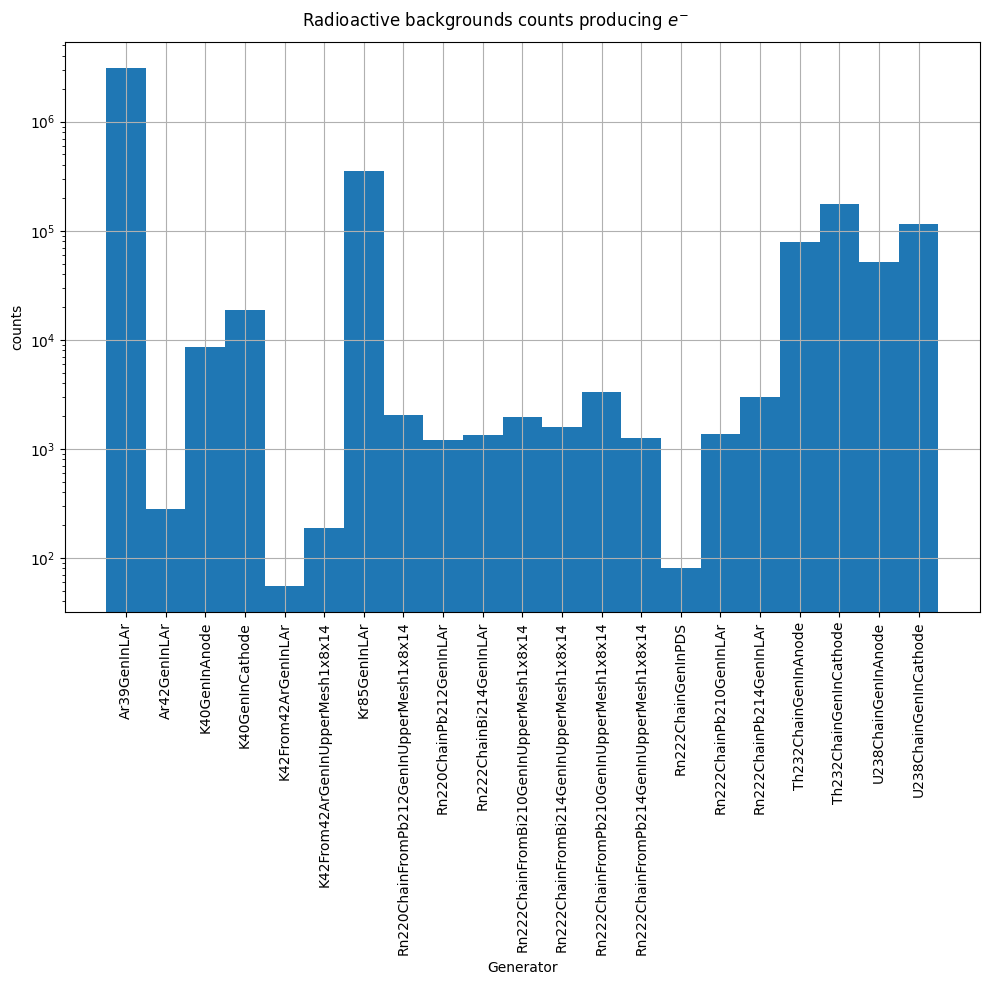

In [16]:
fig = mcp.plot_generator_activity(pdg_id=11)

# MC particles spectra

This is useful to tell the expected energy of clusters from background

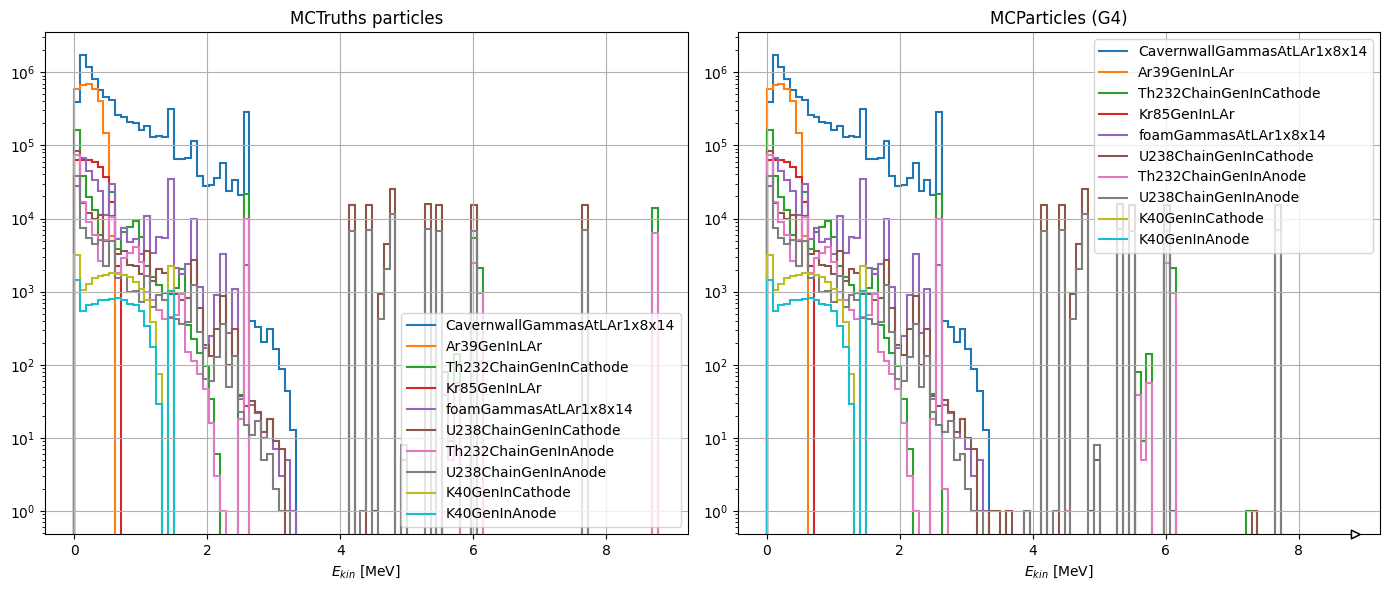

In [50]:
fig = mcp.plot_ke_spectra_by_generator(n_top=10)

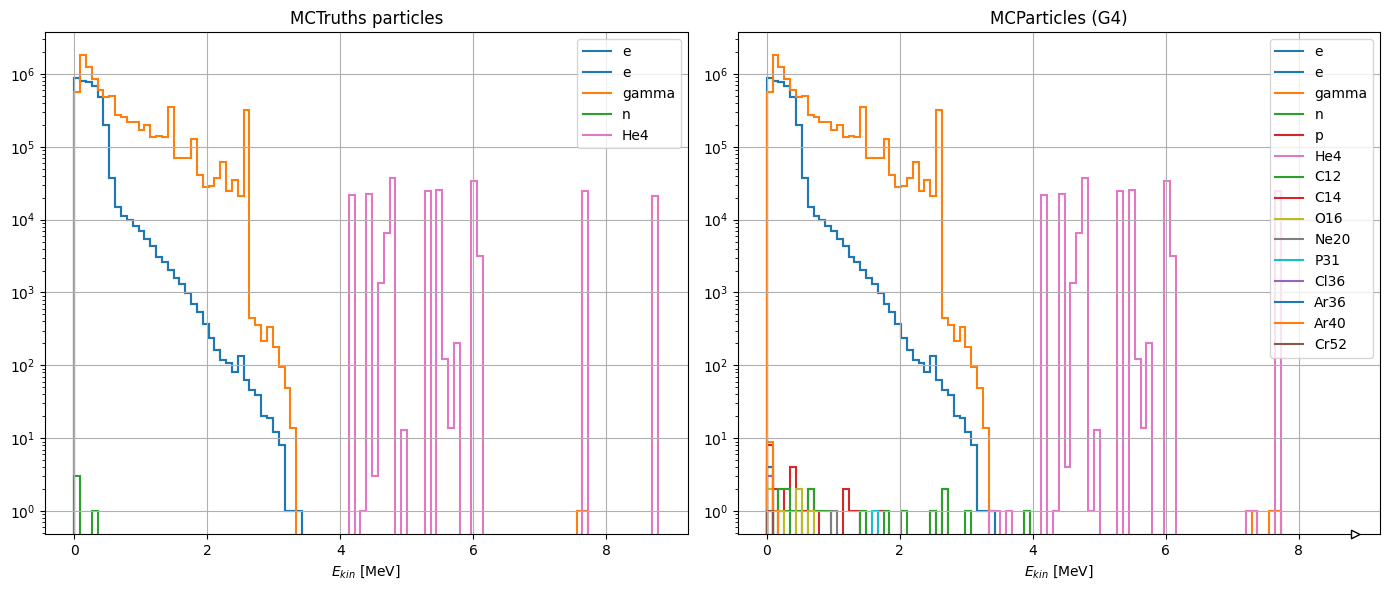

In [ ]:
fig = mcp.plot_ke_spectra_by_pdg()

# TP Spectra, by generator

In [ ]:
# Create a TP preselection - only TPs with peak within the range where backtracking works

rad_sel = snn.TPSignalNoiseSelector(rad_ws.tps)

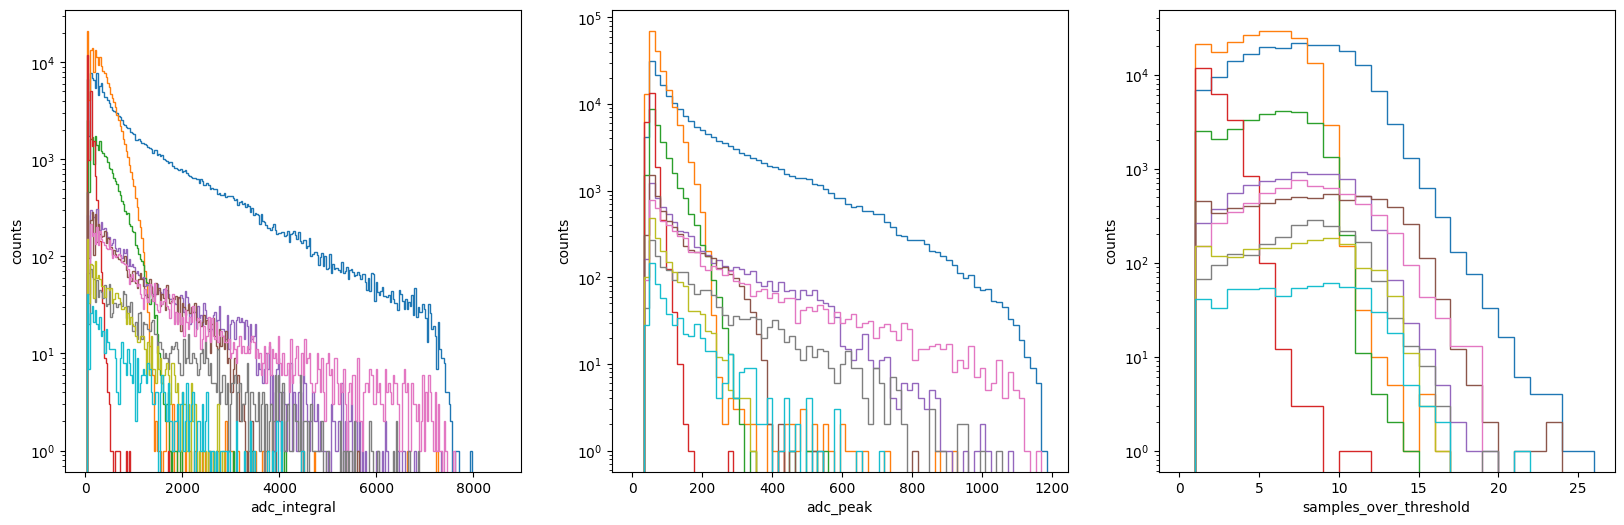

In [ ]:
# Plot rates distributions for the top backgrounds

def plot_tpcounts_by_source(tps, ax, var='adc_integral', binsize=8):

    num_bkg = 10
    tps_by_gen = sorted([(n,df) for n,df in tps.groupby('bt_generator_name')], reverse=True, key=lambda x: len(x[1]))
    top_by_gen = tps_by_gen[:num_bkg]

    bin_max = max([df[var].max() for _, df in top_by_gen])

    bins=np.arange(0, int(bin_max), binsize)

    for n,df in top_by_gen:
        ax.hist(df[var], bins=bins, histtype='step', label=n if n else 'noise')
    # ax.legend()
    ax.set_yscale('log')
    ax.set_xlabel(var)
    ax.set_ylabel('counts')


fig, axes = plt.subplots(1,3, figsize=(20,6))
ro_view = 2

ax = axes[0]
plot_tpcounts_by_source(rad_sel.all_by_view[ro_view], var='adc_integral', binsize=32, ax =ax)
ax = axes[1]
plot_tpcounts_by_source(rad_sel.all_by_view[ro_view], var='adc_peak', binsize=16, ax =ax)
ax = axes[2]
plot_tpcounts_by_source(rad_sel.all_by_view[ro_view], var='samples_over_threshold', binsize=1, ax =ax)


# fig, axes = plt.subplots(1,3, figsize=(20,6))
# ro_view = 2
# sot_thres = 7

# ax = axes[0]
# plot_tpcounts_by_source(rad_sel.all_by_view[ro_view].query(f'samples_over_threshold > {sot_thres}'), var='adc_integral', binsize=64, ax =ax)
# ax = axes[1]
# plot_tpcounts_by_source(rad_sel.all_by_view[ro_view].query(f'samples_over_threshold > {sot_thres}'), var='adc_peak', binsize=16, ax =ax)
# ax = axes[2]
# plot_tpcounts_by_source(rad_sel.all_by_view[ro_view].query(f'samples_over_threshold > {sot_thres}'), var='samples_over_threshold', binsize=1, ax =ax)

# fig = plot_tpcounts_by_source(rad_sel.all_by_view[ro_view].query('samples_over_threshold > 8')f, var=var, binsize=32)
# var = 'adc_peak'
# fig = plot_tpcounts_by_source(rad_sel.all_by_view[ro_view].query('samples_over_threshold > 8'), var=var, binsize=16)
# var = 'samples_over_threshold'
# fig = plot_tpcounts_by_source(rad_sel.all_by_view[ro_view].query('samples_over_threshold > 8'), var=var, binsize=1)


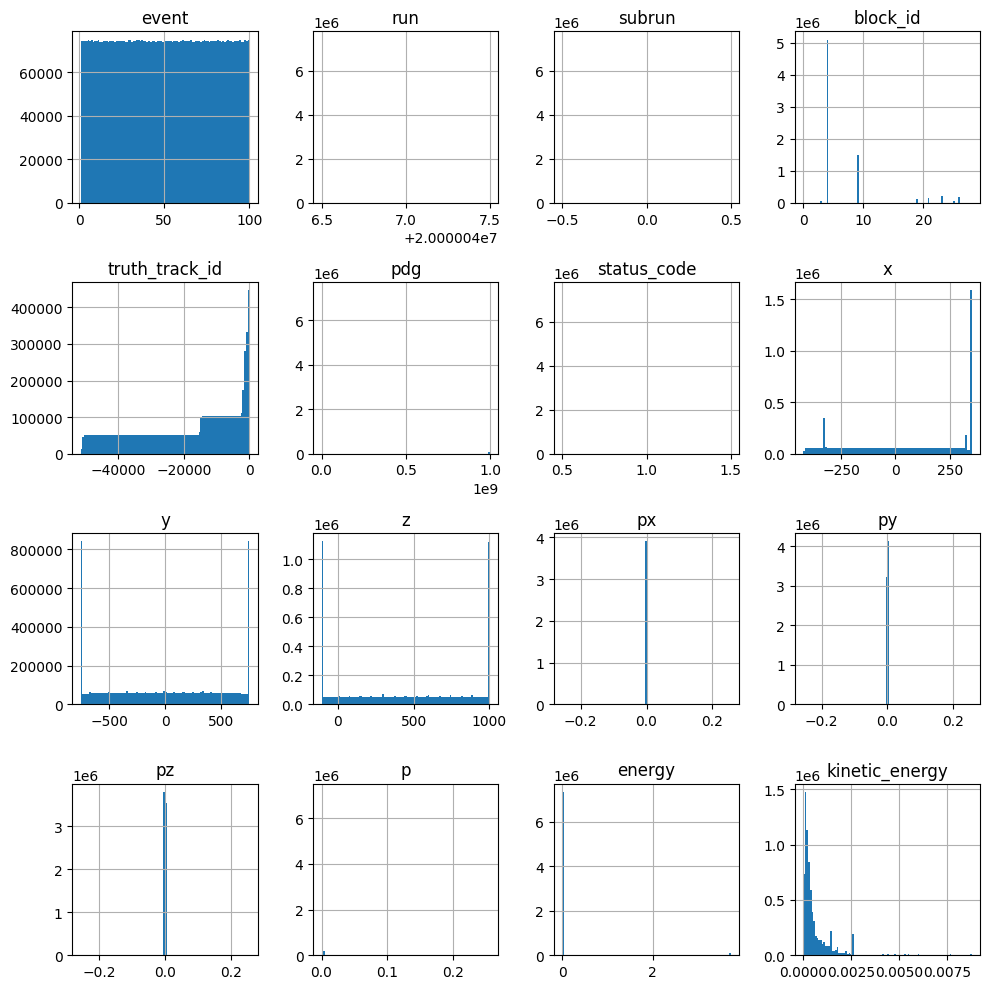

In [ ]:
mct.hist(figsize=(10,10), bins=100)
plt.gcf().tight_layout()

# Wall gammas origin checks

array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'y'}>],
       [<Axes: title={'center': 'z'}>, <Axes: >]], dtype=object)

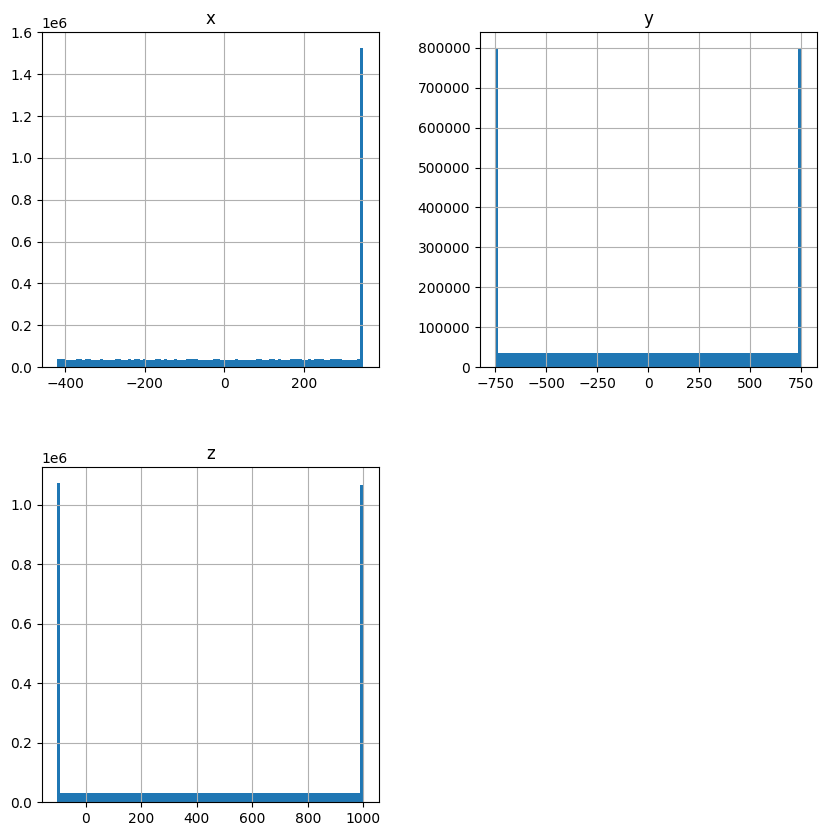

In [ ]:
bkg_gammas = mct.query('generator_name == "CavernwallGammasAtLAr1x8x6"')
bkg_gammas[['x', 'y', 'z']].hist(bins=100, figsize=(10,10))

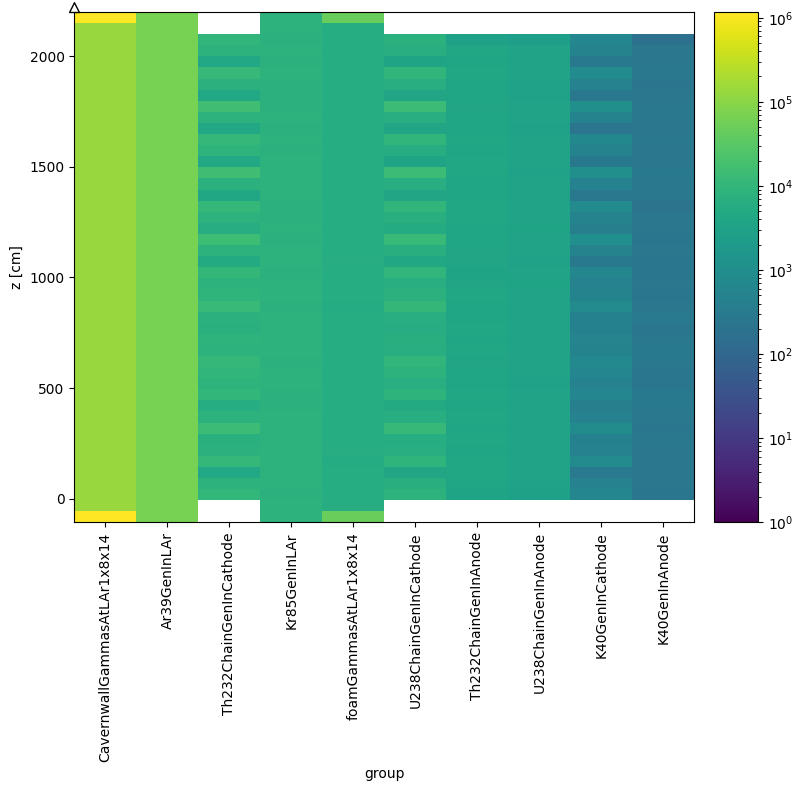

In [25]:
fig = mcp.plot_truth_generator_pos('z', c_scale='log')

Hist(
  StrCategory(['CavernwallGammasAtLAr1x8x14', 'Ar39GenInLAr', 'Th232ChainGenInCathode', 'Kr85GenInLAr', 'foamGammasAtLAr1x8x14', 'U238ChainGenInCathode', 'Th232ChainGenInAnode', 'U238ChainGenInAnode', 'K40GenInCathode', 'K40GenInAnode', 'Rn222ChainPb214GenInLAr', 'Rn222ChainFromBi214GenInUpperMesh1x8x14', 'Rn220ChainFromPb212GenInUpperMesh1x8x14', 'Rn222ChainFromPb210GenInUpperMesh1x8x14', 'Rn222ChainBi214GenInLAr', 'Rn222ChainFromBi210GenInUpperMesh1x8x14', 'Rn222ChainRn222GenInLAr', 'Rn222ChainPo218GenInLAr', 'Rn220ChainPb212GenInLAr', 'Rn222ChainFromPb214GenInUpperMesh1x8x14', 'Rn222ChainPb210GenInLAr', 'Ar42GenInLAr', 'K42From42ArGenInUpperMesh1x8x14', 'Rn222ChainFromPo218GenInUpperMesh1x8x14', 'Rn222ChainGenInPDS', 'K42From42ArGenInLAr', 'CryostatNGammasAtLAr1x8x14', 'CavernNGammasAtLAr1x8x14', 'CavernwallNeutronsAtLAr1x8x14'], name='group'),
  Regular(100, 0, 8.785, name='ke', label='$E_{kin}$ [MeV]'),
  storage=Double()) # Sum: 13208343.0 (13229117.0 with flow)


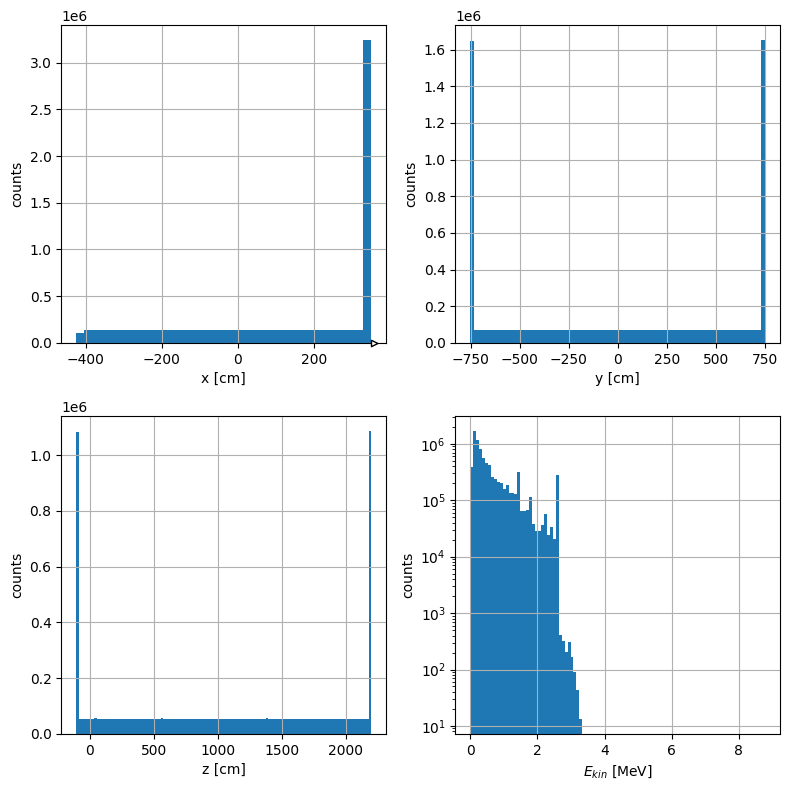

In [49]:
fig = mcp.plot_generator_pos_ke_v2('CavernwallGammasAtLAr1x8x14')

CavernwallGammasAtLAr1x8x14

array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'y'}>],
       [<Axes: title={'center': 'z'}>,
        <Axes: title={'center': 'kinetic_energy'}>]], dtype=object)

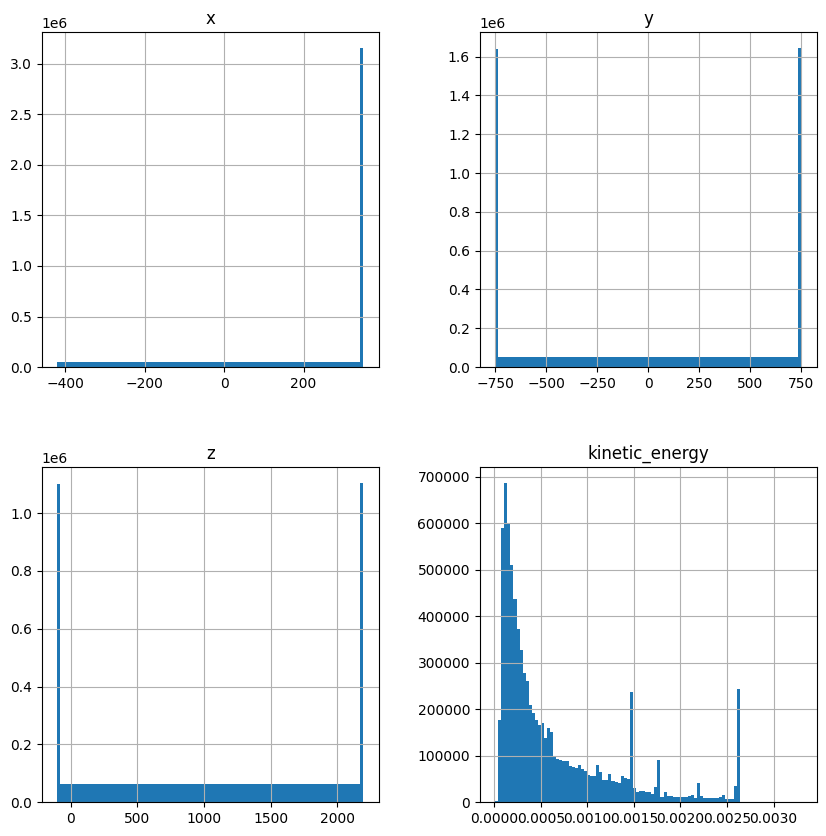

In [ ]:
name, df = list(mct_g.items())[0]
print(name)
df[['x', 'y', 'z', 'kinetic_energy']].hist(bins=100, figsize=(10,10))
# df[['x', 'y', 'z']].plot.scatter(x='z', y='y', figsize=(10,10), s=0.1, alpha=0.01)

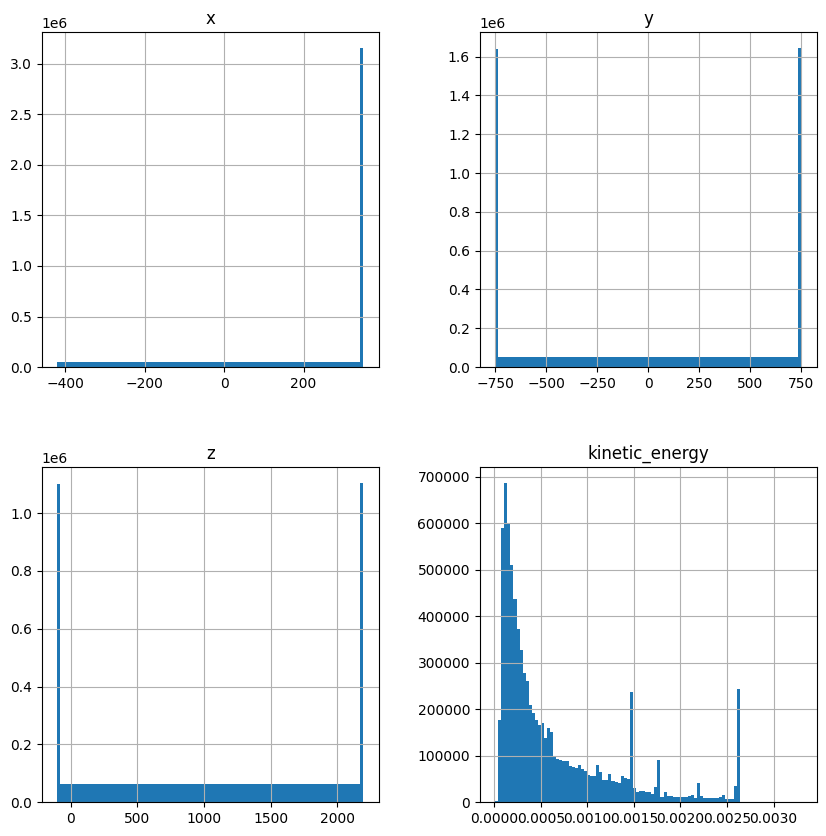

In [ ]:
mcp.plot_generator_pos_ke('CavernwallGammasAtLAr1x8x14')

In [72]:
fig = mcp.plot_truth_generator_origin_2d('CavernwallGammasAtLAr1x8x14', 'xy', bin_width=1)

NameError: name 'Tuple' is not defined